# Las 24 trenzas — Emergencias desde el Sitio Abismal

## Experimento 01 — Una trenza

La trenza es un elemento (algorítmico) compuesto por tres hebras:

- Contención
- Ruido
- Entropía

La trayectoria se construye progresivamente.
El ruido introduce desviaciones.
La entropía acumula esas desviaciones.
La contención mantiene el sistema dentro de ciertos límites.

La forma final no está completamente definida :
emerge de la historia de su recorrido.

Celda 2 — Importar herramientas

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

Celda 3 — Parámetros

In [2]:
# ----------------------------------------------------------
# PARÁMETROS DE LA TRENZA
# ----------------------------------------------------------

longitud = 1000

# Tamaño de cada paso
paso = 0.01

# Intensidad del ruido
ruido = 0.08

# Cuánto se acumula la desviación
entropia = 0.015

# Límite espacial de contención
limite = 1.5

# Separación entre las tres hebras
separacion = 0.18

Celda 4 — Crear la trayectoria

In [3]:
# ----------------------------------------------------------
# TRAYECTORIA BASE
# ----------------------------------------------------------

x = np.linspace(0, longitud * paso, longitud)

y = np.zeros(longitud)

desviacion = 0

for i in range(1, longitud):

    # Ruido nuevo
    r = np.random.normal(0, ruido)

    # Acumulación histórica
    desviacion += r * entropia

    # La nueva posición depende de la anterior
    y[i] = y[i-1] + r + desviacion

    # CONTENCIÓN
    if y[i] > limite:
        y[i] = limite
        desviacion *= -0.5

    if y[i] < -limite:
        y[i] = -limite
        desviacion *= -0.5

Aquí está la parte conceptualmente importante.

No hago:

posición = ruido aleatorio

sino:

posición nueva
      ↓
posición anterior
      +
ruido
      +
historia acumulada
      ↓
contención
      ↓
nueva posición

Por eso la trenza tiene memoria.

Celda 5 — Crear las tres hebras

In [4]:
# ----------------------------------------------------------
# TRES HEBRAS
# ----------------------------------------------------------

hebra_1 = y + separacion
hebra_2 = y
hebra_3 = y - separacion

Por ahora son paralelas. El siguiente paso es tratar de hacer que se entrelacen realmente.

Celda 6 — Dibujar

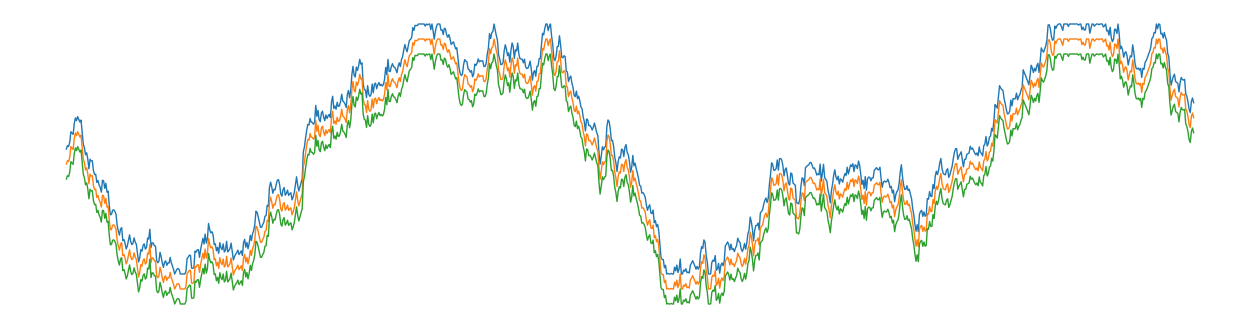

In [5]:
# ----------------------------------------------------------
# VISUALIZACIÓN
# ----------------------------------------------------------

plt.figure(figsize=(16, 4))

plt.plot(x, hebra_1, linewidth=1)
plt.plot(x, hebra_2, linewidth=1)
plt.plot(x, hebra_3, linewidth=1)

plt.axis("off")

plt.show()

el recorrido contiene cierto ruido y acumulación.

Todavía NO es una trenza propiamente tal. Es un primera prueba.

El siguiente paso es importante: hacer que las tres hebras se crucen y se envuelvan entre sí, de manera que la trenza sea realmente una estructura de contención + ruido + entropía, y no simplemente tres líneas con ruido.

Después de eso:  de 1 → 24 trenzas.

Paso 2: convertir las tres trayectorias en una trenza real, pero manteniendo la lógica anterior.

La idea es que las hebras no solo tengan ruido: se alternan alrededor de un eje, produciendo entrelazamiento.

Celda 7 — Entrelazar las tres hebras


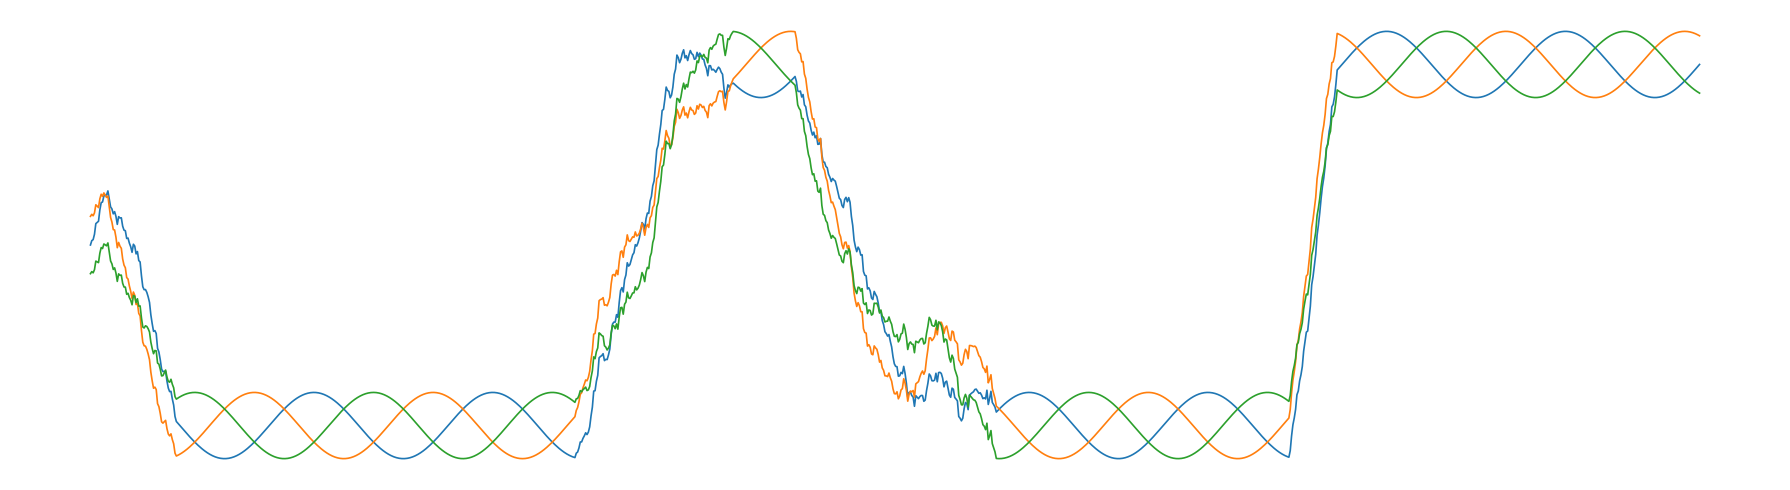

In [16]:
# ----------------------------------------------------------
# TRENZA 3 HEBRAS — VERSIÓN 2
# ----------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

N = 1200

# ----------------------------------------------------------
# 1. EJE: ruido + entropía acumulada
# ----------------------------------------------------------

x = np.linspace(0, 12, N)

eje = np.zeros(N)
memoria = 0

for i in range(1, N):

    # Ruido instantáneo
    ruido = np.random.normal(0, 0.035)

    # Acumulación de desviaciones
    memoria = memoria * 0.995 + ruido * 0.08

    # Nueva posición
    eje[i] = eje[i-1] + ruido + memoria

# ----------------------------------------------------------
# 2. CONTENCIÓN
# ----------------------------------------------------------

limite = 1.2

eje = np.clip(eje, -limite, limite)

# ----------------------------------------------------------
# 3. TORSIÓN
# ----------------------------------------------------------

radio = 0.22

angulo = np.linspace(0, 18 * np.pi, N)

# Tres fases separadas 120 grados
hebra_1 = eje + radio * np.sin(angulo)
hebra_2 = eje + radio * np.sin(angulo + 2*np.pi/3)
hebra_3 = eje + radio * np.sin(angulo + 4*np.pi/3)

# ----------------------------------------------------------
# 4. DIBUJAR
# ----------------------------------------------------------

plt.figure(figsize=(18, 5))

plt.plot(x, hebra_1, linewidth=1.2)
plt.plot(x, hebra_2, linewidth=1.2)
plt.plot(x, hebra_3, linewidth=1.2)

plt.axis("off")
plt.tight_layout()

plt.show()

Paso 3 — Las 24 trenzas

Primero vamos a crear 24 identidades y asignarles tres parámetros:

CONTENCIÓN
RUIDO
ENTROPÍA

Cada trenza será diferente, pero todas obedecerán las mismas reglas.

Celda 10 — Parámetros de las 24

In [17]:
# ----------------------------------------------------------
# 24 TRENZAS — PARÁMETROS
# ----------------------------------------------------------

np.random.seed(42)

n_trenzas = 24

parametros = []

for i in range(n_trenzas):

    parametros.append({
        "id": i + 1,

        # Contención
        "limite": np.random.uniform(0.7, 1.5),

        # Ruido
        "ruido": np.random.uniform(0.015, 0.08),

        # Entropía
        "entropia": np.random.uniform(0.003, 0.04),

        # Torsión
        "torsion": np.random.uniform(12, 25),

        # Densidad
        "radio": np.random.uniform(0.12, 0.30)
    })

parametros[:3]

[{'id': 1,
  'limite': 0.99963209507789,
  'ruido': 0.07679642991664455,
  'entropia': 0.030083775847021987,
  'torsion': 19.782560294561478,
  'radio': 0.14808335527963856},
 {'id': 2,
  'limite': 0.824795616268962,
  'ruido': 0.018775434790932966,
  'entropia': 0.0350485173936726,
  'torsion': 19.814495152661713,
  'radio': 0.24745306400328818},
 {'id': 3,
  'limite': 0.716467595436642,
  'ruido': 0.07804414039052963,
  'entropia': 0.0338003777096156,
  'torsion': 14.76040843881759,
  'radio': 0.15272849409727812}]

Celda 11 — Función que genera una trenza

Ahora se encapsula lo que se hizo antes.

In [18]:
# ----------------------------------------------------------
# TRENZA — 3 HEBRAS CON VARIACIÓN PROPIA
# ----------------------------------------------------------

def generar_trenza(param, N=1200):

    x = np.linspace(0, 12, N)

    # ------------------------------------------------------
    # EJE PRINCIPAL
    # ------------------------------------------------------

    eje = np.zeros(N)
    memoria = 0

    for i in range(1, N):

        ruido_actual = np.random.normal(
            0,
            param["ruido"]
        )

        memoria = (
            memoria * 0.985
            + ruido_actual * param["entropia"]
        )

        eje[i] = (
            eje[i-1]
            + ruido_actual
            + memoria
        )

    # ------------------------------------------------------
    # CONTENCIÓN
    # ------------------------------------------------------

    limite = param["limite"]

    eje = np.tanh(eje / limite) * limite

    # ------------------------------------------------------
    # TORSIÓN
    # ------------------------------------------------------

    angulo = np.linspace(
        0,
        param["torsion"] * np.pi,
        N
    )

    radio = param["radio"]

    # ------------------------------------------------------
    # TRES HEBRAS
    # ------------------------------------------------------

    h1 = eje + radio * np.sin(angulo)

    h2 = eje + radio * np.sin(
        angulo + 2*np.pi/3
    )

    h3 = eje + radio * np.sin(
        angulo + 4*np.pi/3
    )

    # ------------------------------------------------------
    # MICRO-DESVIACIONES INDIVIDUALES
    # ------------------------------------------------------

    h1 += np.random.normal(
        0,
        param["ruido"] * 0.25,
        N
    )

    h2 += np.random.normal(
        0,
        param["ruido"] * 0.35,
        N
    )

    h3 += np.random.normal(
        0,
        param["ruido"] * 0.45,
        N
    )

    return x, h1, h2, h3

In [21]:
# ----------------------------------------------------------
# PALETA BASE
# ----------------------------------------------------------

colores_base = [
    "#E63946",
    "#F4A261",
    "#E9C46A",
    "#2A9D8F",
    "#264653",
    "#457B9D",
    "#A8DADC",
    "#6D597A"
]

In [23]:
# ----------------------------------------------------------
# 24 TRÍADAS CROMÁTICAS
# ----------------------------------------------------------

combinaciones = [
    (0, 1, 2),
    (0, 2, 3),
    (1, 3, 2),

    (3, 4, 5),
    (3, 5, 6),
    (4, 6, 5),

    (6, 7, 0),
    (6, 0, 1),
    (7, 1, 0),

    (1, 2, 4),
    (1, 4, 5),
    (2, 5, 4),

    (2, 3, 6),
    (2, 6, 7),
    (3, 7, 6),

    (0, 4, 6),
    (0, 6, 7),
    (4, 7, 6),

    (1, 5, 7),
    (1, 7, 3),
    (5, 3, 7),

    (0, 2, 5),
    (2, 4, 7),
    (0, 5, 3)
]

In [24]:
# ----------------------------------------------------------
# CONVERTIR ÍNDICES EN COLORES
# ----------------------------------------------------------

paletas = []

for combinacion in combinaciones:

    paleta = [
        colores_base[i]
        for i in combinacion
    ]

    paletas.append(paleta)

print("Número de trenzas:", len(paletas))

for i, paleta in enumerate(paletas):
    print(f"Trenza {i+1:02d}:", paleta)

Número de trenzas: 24
Trenza 01: ['#E63946', '#F4A261', '#E9C46A']
Trenza 02: ['#E63946', '#E9C46A', '#2A9D8F']
Trenza 03: ['#F4A261', '#2A9D8F', '#E9C46A']
Trenza 04: ['#2A9D8F', '#264653', '#457B9D']
Trenza 05: ['#2A9D8F', '#457B9D', '#A8DADC']
Trenza 06: ['#264653', '#A8DADC', '#457B9D']
Trenza 07: ['#A8DADC', '#6D597A', '#E63946']
Trenza 08: ['#A8DADC', '#E63946', '#F4A261']
Trenza 09: ['#6D597A', '#F4A261', '#E63946']
Trenza 10: ['#F4A261', '#E9C46A', '#264653']
Trenza 11: ['#F4A261', '#264653', '#457B9D']
Trenza 12: ['#E9C46A', '#457B9D', '#264653']
Trenza 13: ['#E9C46A', '#2A9D8F', '#A8DADC']
Trenza 14: ['#E9C46A', '#A8DADC', '#6D597A']
Trenza 15: ['#2A9D8F', '#6D597A', '#A8DADC']
Trenza 16: ['#E63946', '#264653', '#A8DADC']
Trenza 17: ['#E63946', '#A8DADC', '#6D597A']
Trenza 18: ['#264653', '#6D597A', '#A8DADC']
Trenza 19: ['#F4A261', '#457B9D', '#6D597A']
Trenza 20: ['#F4A261', '#6D597A', '#2A9D8F']
Trenza 21: ['#457B9D', '#2A9D8F', '#6D597A']
Trenza 22: ['#E63946', '#E9C46A',

parámetros
     ↓
generar_trenza()
     ↓
forma

Esto significa que posteriormente el diccionario: documento para la obra 2025 TTT2, podrá controlar esos parámetros.

Celda 12 — Dibujar las 24

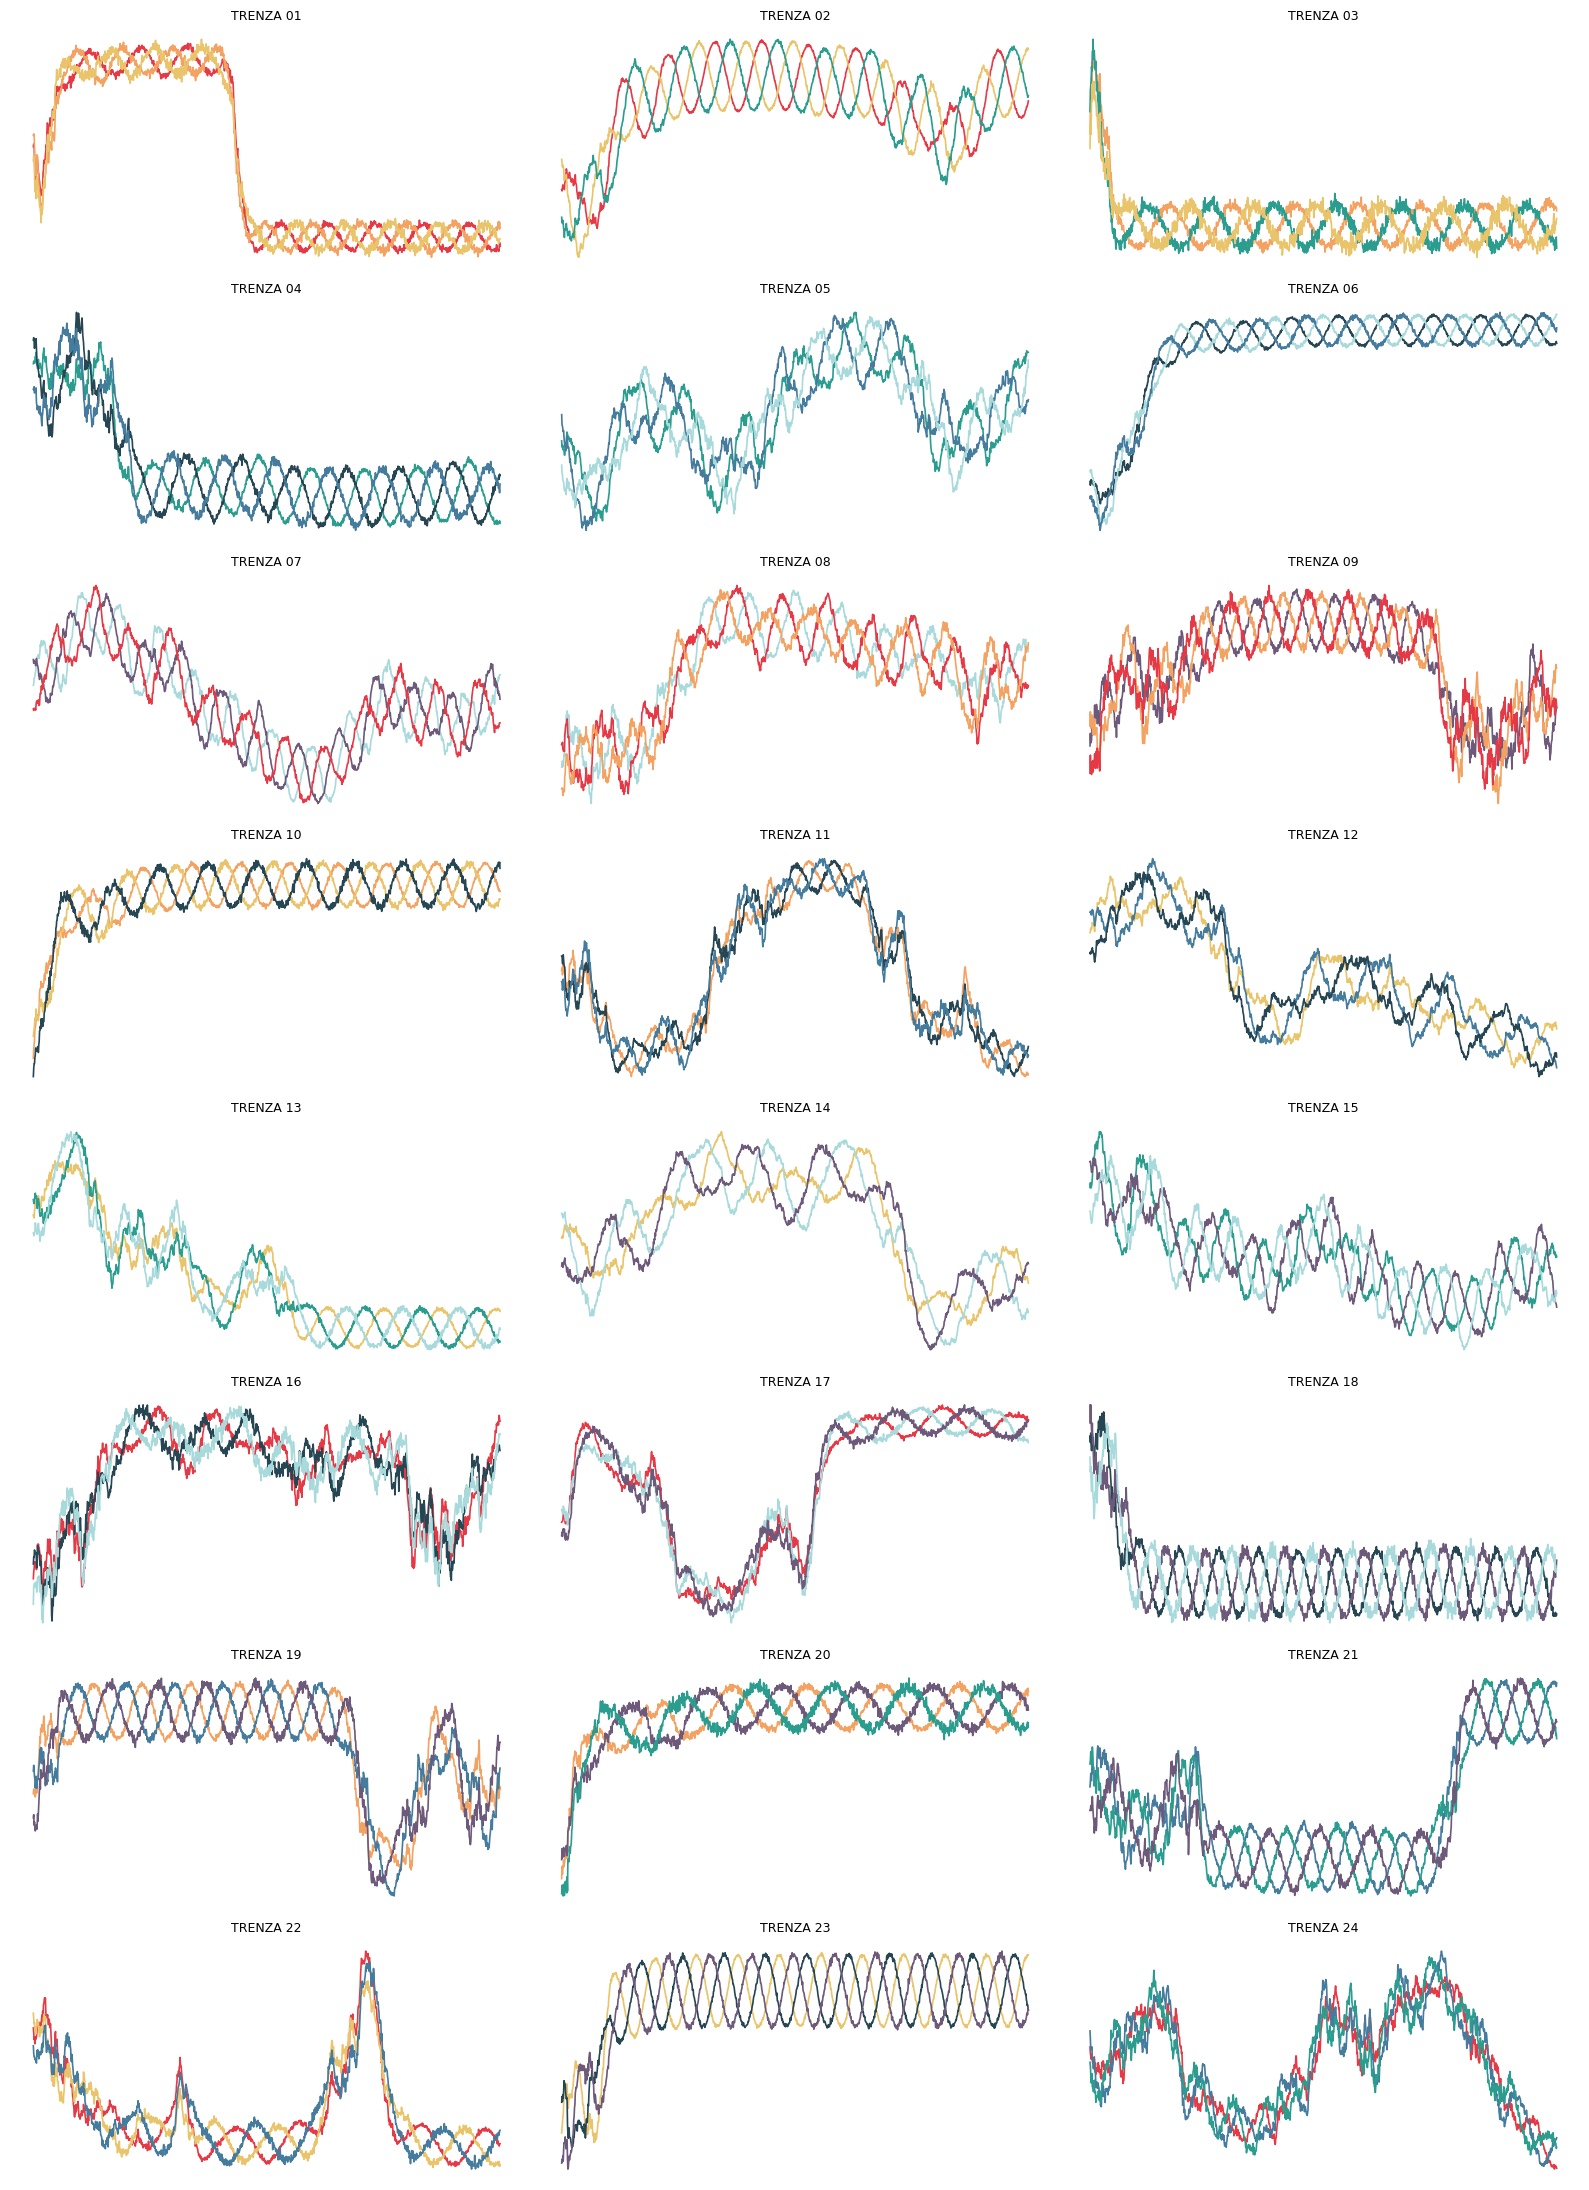

In [26]:
# ----------------------------------------------------------
# DIBUJAR 24 TRENZAS
# ----------------------------------------------------------

fig, axes = plt.subplots(
    8,
    3,
    figsize=(16, 22)
)

for i, param in enumerate(parametros):

    x, h1, h2, h3 = generar_trenza(param)

    ax = axes.flat[i]

    colores = paletas[i]

    ax.plot(x, h1, color=colores[0], linewidth=1.2)
    ax.plot(x, h2, color=colores[1], linewidth=1.2)
    ax.plot(x, h3, color=colores[2], linewidth=1.2)

    ax.set_title(
        f"TRENZA {i+1:02d}",
        fontsize=9
    )

    ax.axis("off")

plt.tight_layout()
plt.show()